In [1]:
import sys, os, time
sys.path.append(os.path.abspath('..'))
from tqdm import tqdm 
import torch
import torchvision
from ultralytics import YOLO
from torchvision.models.detection import _utils
from torchvision.models.detection.ssd import SSDClassificationHead
from torchvision.models.detection import fasterrcnn_resnet50_fpn_v2
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchmetrics.detection.mean_ap import MeanAveragePrecision
from torch.utils.data import DataLoader

from CustomDataset import CustomDataset
import albumentations as A

from proposal_codes.utils import show_img_with_boxes, to_device



# Load models

In [2]:
# Load SSD

num_class = 4
ssd_model = torchvision.models.detection.ssd300_vgg16()

in_channels = _utils.retrieve_out_channels(ssd_model.backbone, (300, 300))
num_anchors = ssd_model.anchor_generator.num_anchors_per_location()

# Replace the classification head for 4 classes + background
ssd_model.head.classification_head = SSDClassificationHead(
    in_channels=in_channels,
    num_anchors=num_anchors,
    num_classes=num_class + 1
)

# Adjust transform sizes
ssd_model.transform.min_size = (300,)
ssd_model.transform.max_size = 300


In [3]:
ssd_state_dict = torch.load("./SSD_mobile_detection.pth", weights_only=True)
ssd_model.load_state_dict(ssd_state_dict)

for param in ssd_model.parameters():
    param.requires_grad = False


print(ssd_model)

SSD(
  (backbone): SSDFeatureExtractorVGG(
    (features): Sequential(
      (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
      (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (6): ReLU(inplace=True)
      (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (8): ReLU(inplace=True)
      (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (11): ReLU(inplace=True)
      (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (13): ReLU(inplace=True)
      (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (15): ReLU(inplace=

In [4]:
#load RCNN 
RCNN_model = fasterrcnn_resnet50_fpn_v2(
    progress=True,
    trainable_backbone_layers = 1
    )

# Replace the classification head
in_features = RCNN_model.roi_heads.box_predictor.cls_score.in_features
RCNN_model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_class + 1)

rcnn_state_dict = torch.load("./fasterRCNN.pth", weights_only=True)
RCNN_model.load_state_dict(rcnn_state_dict)

print(RCNN_model)


/home/kien/torch_cuda/lib/python3.13/site-packages/torchvision/models/detection/backbone_utils.py:162: UserWarning: Changing trainable_backbone_layers has no effect if neither pretrained nor pretrained_backbone have been set to True, falling back to trainable_backbone_layers=5 so that all layers are trainable
  warnings.warn(


FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
       

In [5]:
#Load Yolo
yolov11 = YOLO("./runs/detect/train4/weights/best.pt")

# Load dataset

In [6]:
test_transforms = A.Compose([
    A.RandomCrop(width=300, height=300, p=1.0),
    A.Normalize(),
    A.pytorch.ToTensorV2(),
],  bbox_params=A.BboxParams(format='pascal_voc', 
                        label_fields=["class_labels"],
                        clip=True,
                        min_visibility=0.1
                        ))

test_image_dir = "../data/incabinDetection/test/images"
test_label_dir = "../data/incabinDetection/test/labels"
test_labels = os.listdir(test_label_dir)

test_datset = CustomDataset(
    test_image_dir,
    test_labels,
    test_label_dir,
    transform=test_transforms)

test_loader = DataLoader(
    test_datset,
    shuffle=False,
    batch_size=4,
    collate_fn=lambda x: tuple(zip(*x)))

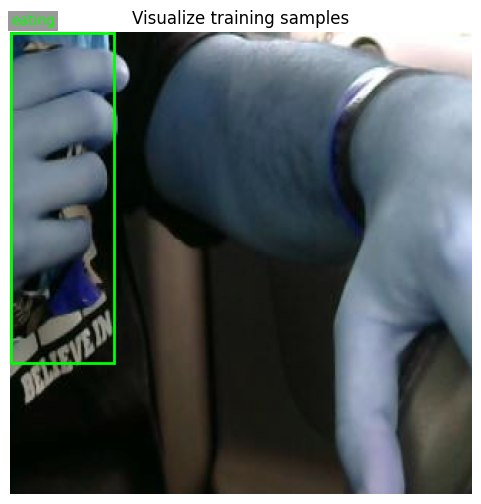

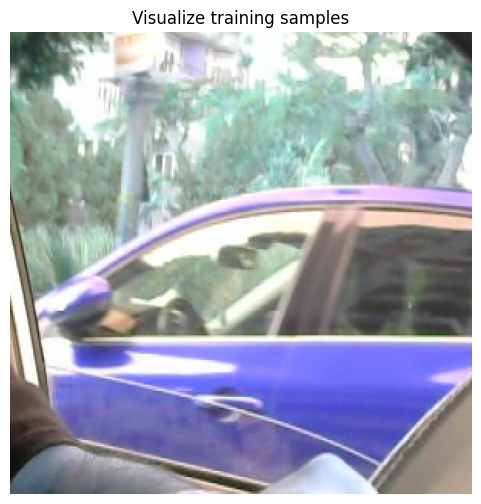

In [7]:
sample_iter = iter(test_loader)

label_names = {
    1:'drinking',
    2:'eating',
    3: 'mobile use',
    4: 'smoking'}

for _ in range(2):
    sample = next(sample_iter)
    img, target = sample
    show_img_with_boxes(img[0], target[0], label_names=label_names, title="Visualize training samples")


# eval

In [14]:
def torch_eval(model, dataloader):

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    model.eval()
    result = {}
    run_time = 0

    metric = MeanAveragePrecision().to(device)

    loop = tqdm(
        enumerate(dataloader),
        total=len(dataloader),
        leave=True
        )

    with torch.no_grad():
        for i, (image, label) in loop:
            image = to_device(image)
            label = to_device(label)
            
            for t in label:
                if t["boxes"].ndim == 1:
                    t["boxes"] = t["boxes"].view(-1,4)
            start_time = time.perf_counter()
            output = model(image)
            run_time += time.perf_counter() - start_time
            metric.update(output, label)
            
    
    metric_results = metric.compute()
    result["map"] = metric_results['map'].item()
    result["map_50"] = metric_results['map_50'].item()
    result["FPS"] = len(test_loader) / run_time
    result["total_time"] = run_time
    result["inference_time (s/im)"] = run_time / len(test_loader)

    return result



print(torch_eval(ssd_model,test_loader))
print(torch_eval(RCNN_model,test_loader))


  0%|          | 0/68 [00:00<?, ?it/s]/home/kien/torch_cuda/lib/python3.13/site-packages/torchmetrics/utilities/prints.py:43: UserWarning: Encountered more than 100 detections in a single image. This means that certain detections with the lowest scores will be ignored, that may have an undesirable impact on performance. Please consider adjusting the `max_detection_threshold` to suit your use case. To disable this warning, set attribute class `warn_on_many_detections=False`, after initializing the metric.
  warnings.warn(*args, **kwargs)
100%|██████████| 68/68 [00:02<00:00, 23.18it/s]


{'map': 0.4270433783531189, 'map_50': 0.8012392520904541, 'FPS': 29.427100883892194, 'total_time': 2.3107950819994585, 'inference_time (s/im)': 0.033982280617639096}


100%|██████████| 68/68 [00:13<00:00,  4.99it/s]


{'map': 0.44306570291519165, 'map_50': 0.8273124098777771, 'FPS': 5.2410231797399645, 'total_time': 12.97456577999219, 'inference_time (s/im)': 0.1908024379410616}


In [12]:
from ultralytics.utils.benchmarks import benchmark

benchmark(model="./runs/detect/train4/weights/best.pt", data="../data/incabinDetection/data.yaml", imgsz=640, half=False, device=0)
    
    

Setup complete ✅ (24 CPUs, 15.3 GB RAM, 111.0/1006.9 GB disk)

Benchmarks complete for ./runs/detect/train4/weights/best.pt on ../data/incabinDetection/data.yaml at imgsz=640 (142.35s)
Benchmarks legend:  - ✅ Success  - ❎ Export passed but validation failed  - ❌️ Export failed
+-----------------------------------------------------------------------------------------------------------+
|      Format                  Status❔   Size (MB)   metrics/mAP50-95(B)   Inference time (ms/im)   FPS    |
+===========================================================================================================+
| 1    PyTorch                 ✅         38.7        0.6041                11.61                    86.1   |
| 2    TorchScript             ✅         77.1        0.6038                9.05                     110.49 |
| 3    ONNX                    ✅         76.7        0.6039                13.37                    74.81  |
| 4    OpenVINO                ❌         0.0         -            

,Format,Status❔,Size (MB),metrics/mAP50-95(B),Inference time (ms/im),FPS
"""1""","""PyTorch""","""✅""","""38.7""","""0.6041""","""11.61""","""86.1"""
"""2""","""TorchScript""","""✅""","""77.1""","""0.6038""","""9.05""","""110.49"""
"""3""","""ONNX""","""✅""","""76.7""","""0.6039""","""13.37""","""74.81"""
"""4""","""OpenVINO""","""❌""","""0.0""","""-""","""-""","""-"""
"""5""","""TensorRT""","""✅""","""78.9""","""0.604""","""5.87""","""170.31"""
"""6""","""CoreML""","""❌""","""0.0""","""-""","""-""","""-"""
"""7""","""TensorFlow SavedModel""","""❌""","""0.0""","""-""","""-""","""-"""
"""8""","""TensorFlow GraphDef""","""❌""","""0.0""","""-""","""-""","""-"""
"""9""","""TensorFlow Lite""","""❌""","""0.0""","""-""","""-""","""-"""
"""10""","""TensorFlow Edge TPU""","""❌""","""0.0""","""-""","""-""","""-"""


In [15]:
yolo_resutl = yolov11.val(data="../data/incabinDetection/data.yaml", imgsz=640, batch=4, conf=0.25, iou=0.6, device="0")

Ultralytics 8.3.241 🚀 Python-3.13.9 torch-2.9.1+cu128 CUDA:0 (NVIDIA GeForce RTX 5070 Ti Laptop GPU, 12227MiB)
YOLO11m summary (fused): 125 layers, 20,033,116 parameters, 0 gradients, 67.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 71.5±23.5 MB/s, size: 40.2 KB)
val: Scanning /home/kien/obj_detectin_amir/Amir_research/data/incabinDetection/test/labels.cache... 270 images, 1 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 270/270 547.6Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 68/68 18.5it/s 3.7s0.1s
                   all        270        271      0.968       0.94      0.959      0.623
              drinking         88         88      0.983          1      0.995      0.738
                eating         69         69      0.937      0.899      0.934      0.667
            mobile use         65         65      0.993      0.923       0.96      0.605
               smoking         49         49      0.958

In [16]:
yolo_resutl

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x77fa984ae4e0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0